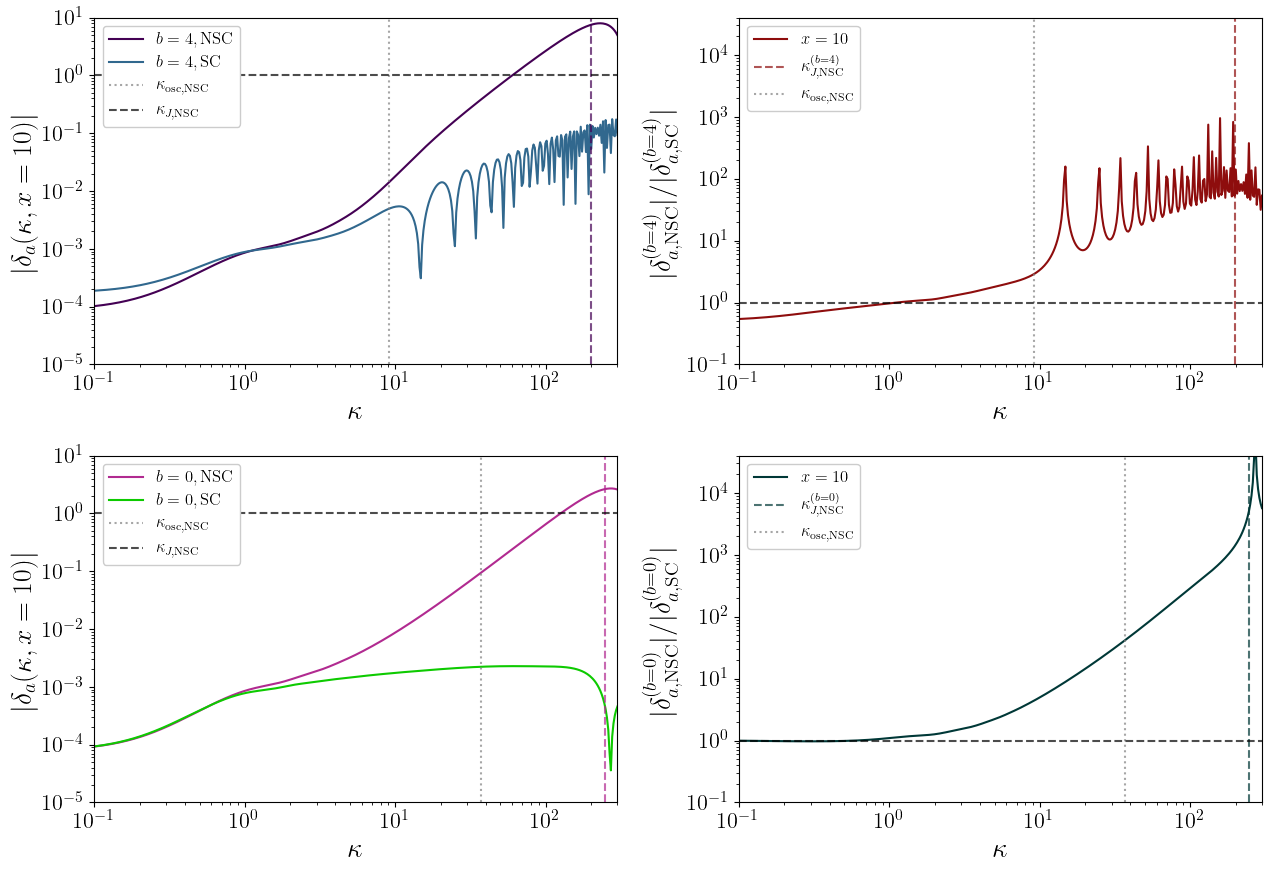

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "pdf.fonttype": 42,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

ymin = 1e-5
ymax = 1e1
eps = 1e-50

lab_k = r'$\kappa$'
lab_da10 = r'$|\delta_a(\kappa,x=10)|$'

color_sc_b4 = '#31688e'
color_nsc_b4 = '#440154'
color_ratio_b4 = "#8e0d0d"

color_sc_b0 = "#0dca00"
color_nsc_b0 = '#b12a90'
color_ratio_b0 = "#003837"
k_Jb4= 199.63653326510797 
k_oscb4= 9.107049572614699
k_Jb0= 123.33835713588856 *2
k_oscb0= 36.975472555045606
def load_run(path, cosmo):
    axion_file = os.path.join(path, f"0_{cosmo}.npz")
    
    if not os.path.exists(axion_file):
        print(f"Archivo no encontrado para {cosmo} en {path}")
        return None
        
    with np.load(axion_file, allow_pickle=True) as f_ax:
        scale_factors = f_ax['scale_factors'].item()
        kappas = scale_factors['kappas']
        delta_a_spec = np.abs(scale_factors['delta_a_spec_s'])
        kappa_J = scale_factors['kappa_J']
        
    return {"kappas": kappas, "delta_a": delta_a_spec, "kappa_J": kappa_J}

path_b0 = "Sim_Data/Varying_Cosmo/B0/Run_Tend_0.015000_Tl_0.025000"
path_b4 = "Sim_Data/Varying_Cosmo/B4/Run_Tend_0.015000_Tl_0.025000"

b0_sc = load_run(path_b0, "SC")
b0_nsc = load_run(path_b0, "NSC")

b4_sc = load_run(path_b4, "SC")
b4_nsc = load_run(path_b4, "NSC")

if b0_nsc is not None:
    b0_nsc["kappa_J"] = k_Jb0

def plot_panel_separate(ax, run1, lbl1, c1, run2, lbl2, c2, plot_kj2=True):
    if not run1 or not run2:
        return
        
    k1, da1, kj1 = run1["kappas"], run1["delta_a"], run1["kappa_J"]
    k2, da2, kj2 = run2["kappas"], run2["delta_a"], run2["kappa_J"]
    f6 = 6**(1/4)

    ax.plot(k1, da1, color=c1, label=lbl1)
    
    
    ax.plot(k2, da2, color=c2, label=lbl2)
    if kj1==k_Jb0:
        kj1 = k_Jb0
        kosc=k_oscb0
        ax.axvline(kosc, color='gray', linestyle=':', alpha=0.7,label=r'$\kappa_{\text{osc}, \text{NSC}}$')
        ax.axvline(kj1, color=c1, linestyle='--', alpha=0.7)
        
    else:
        kj1 =k_Jb4
        kosc=k_oscb4
        ax.axvline(kosc, color='gray', linestyle=':', alpha=0.7,label=r'$\kappa_{\text{osc}, \text{NSC}}$')
        ax.axvline(kj1, color=c1, linestyle='--', alpha=0.7)
        

    
    ax.plot([], [], color='black', linestyle='--', alpha=0.7, label=r'$\kappa_{J, \text{NSC}}$')

    k_max = max(k1[-1], k2[-1])
    ax.set_xlim(1e-1, k_max)
    ax.set_ylim(ymin, ymax)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.7)
    ax.set_ylabel(lab_da10)
    ax.set_xlabel(lab_k)
    ax.legend(loc='upper left', prop={'size': 12}, framealpha=1)

def plot_panel_ratio(ax, run_num, run_den, line_color, ylabel_text, kj_label):
    if not run_num or not run_den:
        return
        
    k_num, da_num, kj_num_raw = run_num["kappas"], run_num["delta_a"], run_num["kappa_J"]
    k_den, da_den = run_den["kappas"], run_den["delta_a"]
    


    da_den_interp = np.interp(k_num, k_den, da_den)
    ratio_spec = da_num / (da_den_interp + eps)
    f6 = 6**(1/4)
    ax.plot(k_num, ratio_spec, color=line_color, label=r'$x=10$')
    if kj_num_raw==k_Jb0:
        kj_num = kj_num_raw
        kosc=k_oscb0
        ax.axvline(kj_num, color=line_color, linestyle='--', alpha=0.7, label=kj_label)
        ax.axvline(kosc, color='gray', linestyle=':', alpha=0.7,label=r'$\kappa_{\text{osc}, \text{NSC}}$')
    else:
        kj_num = k_Jb4
        kosc=k_oscb4
        ax.axvline(kj_num, color=line_color, linestyle='--', alpha=0.7, label=kj_label)
        ax.axvline(kosc, color='gray', linestyle=':', alpha=0.7,label=r'$\kappa_{\text{osc}, \text{NSC}}$')
    
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.7)
    
    
    k_max = max(k_num[-1], k_den[-1])
    ax.set_xlim(1e-1, k_max)
    ax.set_ylim(1e-1, 4e4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel(ylabel_text)
    ax.set_xlabel(lab_k)
    ax.legend(loc='upper left', prop={'size': 12}, framealpha=1)

fig, axs = plt.subplots(2, 2, figsize=(13, 9))

plot_panel_separate(
    axs[0, 0], 
    b4_nsc, r'$b=4, \text{NSC}$', color_nsc_b4,
    b4_sc, r'$b=4, \text{SC}$', color_sc_b4,
    plot_kj2=True
)

plot_panel_ratio(
    axs[0, 1], 
    b4_nsc, b4_sc, color_ratio_b4, 
    r'$|\delta_{a,\text{NSC}}^{(b=4)}| / |\delta_{a,\text{SC}}^{(b=4)}|$', 
    r'$\kappa_{J, \text{NSC}}^{(b=4)}$'
)

plot_panel_separate(
    axs[1, 0], 
    b0_nsc, r'$b=0, \text{NSC}$', color_nsc_b0,
    b0_sc, r'$b=0, \text{SC}$', color_sc_b0,
    plot_kj2=False
)

plot_panel_ratio(
    axs[1, 1], 
    b0_nsc, b0_sc, color_ratio_b0, 
    r'$|\delta_{a,\text{NSC}}^{(b=0)}| / |\delta_{a,\text{SC}}^{(b=0)}|$', 
    r'$\kappa_{J, \text{NSC}}^{(b=0)}$'
)

fig.tight_layout()

os.makedirs("Plots", exist_ok=True)
fig.savefig("Plots/NSC_pert/ALP_perturbations/ALP_delta_a/Spectra_cosmosb.pdf", bbox_inches='tight', dpi=300)
plt.show()